In [10]:
import pandas as pd
import numpy as np
import pint
ureg = pint.get_application_registry()
import plotly.graph_objects as go

In [2]:
from aircraftdetective.processing.usdot import process_data_usdot_t2
from aircraftdetective.processing.acftdb import _read_engine_database
from aircraftdetective.processing.literature import process_data_weinold_database

from aircraftdetective.calculations.weight import calculate_weight_metrics

from aircraftdetective.calculations.engines import (
    determine_takeoff_to_cruise_tsfc_ratio,
    scale_engine_data_from_icao_emissions_database
)
from aircraftdetective.calculations.aerodynamics import compute_lift_to_drag_ratio
from aircraftdetective.processing.a4a import process_a4a_traffic_data
from aircraftdetective.utility.tabular import (
    left_merge_wildcard,
    export_typed_dataframe_to_excel
)
from aircraftdetective.utility.statistics import _compute_polynomials_from_dataframe
from aircraftdetective.utility.tabular import update_column_data
from aircraftdetective.calculations.decomposition import compute_efficiency_improvement_metrics

In [3]:
df_acft = process_data_weinold_database()
df_engines_acftdb = _read_engine_database()
df_literature = process_data_weinold_database(sheet_name='Literature Data')
df_operations = process_a4a_traffic_data()

In [4]:
dict_tsfc_scaling = determine_takeoff_to_cruise_tsfc_ratio(degree=1, plot=True)
df_engines_icao_scaled = scale_engine_data_from_icao_emissions_database(
    scaling_polynomial=dict_tsfc_scaling['polynomial'],
)
df_engines_icao_scaled.drop(columns=['Final Test Date'], inplace=True)

In [17]:
df_merged = left_merge_wildcard(
    df_left=df_acft,
    df_right=df_engines_icao_scaled,
    left_on='Engine Designation (ICAO)',
    right_on='Engine Identification',
)
df_merged = left_merge_wildcard(
    df_left=df_merged,
    df_right=df_engines_acftdb,
    left_on='Engine Designation (aircraft-database.com)',
    right_on='Engine Designation',
)
df_merged = update_column_data(
    df_main=df_merged,
    df_other=df_literature,
    merge_column='Aircraft Designation (Literature)',
    list_columns=['TSFC (cruise)'],
)
df_merged = compute_lift_to_drag_ratio(
    df_merged,
    beta = {
        'Wide': 0.04,
        'Narrow': 0.06,
        'Regional': 0.09
    }
)
df_merged = calculate_weight_metrics(df_merged)

In [18]:
df_t2 = process_data_usdot_t2()
df_t2 = df_t2.groupby('Aircraft Designation (US DOT Schedule T2)').mean()
df_t2.drop(columns=['Year'], inplace=True)
df_merged = pd.merge(
    how='left',
    left=df_merged,
    right=df_t2,
    left_on='Aircraft Designation (US DOT Schedule T2)',
    right_on='Aircraft Designation (US DOT Schedule T2)'
)

In [23]:
df_merged = update_column_data(
    df_main=df_merged,
    df_other=df_literature,
    merge_column='Aircraft Designation (Literature)',
    list_columns=['L/D', 'TSFC (cruise)', 'Energy Use (per ASK)'],
)

In [24]:
df_merged.head(4)

,Manufacturer,Aircraft Designation,Aircraft Designation (Literature),Aircraft Designation (aircraft-database.com),Aircraft Designation (US DOT Schedule T2),Type,YOI,Engine Designation (ICAO),Engine Designation (aircraft-database.com),Design Range,...,Updated?(L/D),Updated?(L/D),Fuel/Available Seat Distance,Fuel/Revenue Seat Distance,Fuel Flow,Energy Use (per ASK),Updated?(Energy Use (per ASK)),Energy Intensity (per RPK),Airborne Efficiency,Revenue Passenger Distance
0,Airbus,A220-100,NaN,A220-100,A200-100 BD-500-1A10,Narrow,2016,PW1519G,PW1519G,6700.0,...,False,False,0.014342237147026128,0.019219012506973217,672.7058856593372,1.1706056571081447,False,1.5686454305603215,0.8278189758393693,716976819.0
1,Airbus,A220-300,NaN,A220-300,A220-300 BD-500-1A11,Narrow,2016,PW1521G,PW1521G,6300.0,...,False,False,0.013380505469806998,0.016912406439006062,840.4810493380713,1.0921096365479037,False,1.380381487899033,0.8150626646059727,483745589.4680851
2,Airbus,A300-600,A300-600,A300 B4-600,Airbus Industrie A300-600/R/CF/RCF,Wide,1984,CF6-80C2A5,CF6-80C2A5,6852.0,...,True,True,0.0167187036552123,0.02339057742031206,1967.2451931194253,1.3176,True,1.9091263078801362,0.8592071245393107,820130276.8352941
3,Airbus,A300-600,A300-600,A300 B4-601,Airbus Industrie A300-600/R/CF/RCF,Wide,1986,PW4158,PW4158,6852.0,...,True,True,0.0167187036552123,0.02339057742031206,1967.2451931194253,1.3176,True,1.9091263078801362,0.8592071245393107,820130276.8352941


In [8]:
poly_engines = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='TSFC (cruise)',
    degree=3,
    plot=True
)

In [14]:
poly_aero = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='L/D',
    degree=3,
    plot=True
)

In [15]:
poly_weight = _compute_polynomials_from_dataframe(
    df_acft,
    col_name_x='YOI',
    col_name_y='OEW/Exit Limit',
    degree=1,
    plot=True
)

In [32]:
poly_eu = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='Energy Use (per ASK)',
    degree=5,
    plot=True
)

In [34]:
poly_ei = _compute_polynomials_from_dataframe(
    df_merged,
    col_name_x='YOI',
    col_name_y='Energy Intensity (per RPK)',
    degree=5,
    plot=True
)

In [33]:
poly_weight = _compute_polynomials_from_dataframe(
    df_acft,
    col_name_x='YOI',
    col_name_y='OEW/Exit Limit',
    degree=1,
    plot=True
)

In [37]:
years = np.arange(1950, 2025)
df = pd.DataFrame({
    'Year': years,
    'TSFC (cruise)': poly_engines['polynomial'](years),
    'L/D': poly_aero['polynomial'](years),
    'OEW/Exit Limit': poly_weight['polynomial'](years),
    'Energy Use (per ASK)': poly_eu['polynomial'](years),
    'Energy Intensity (per RPK)': poly_ei['polynomial'](years)
})
df = pd.merge(
    left=df,
    right=df_operations,
    left_on='Year',
    right_on='Year'
)
df

,Year,TSFC (cruise),L/D,OEW/Exit Limit,Energy Use (per ASK),Energy Intensity (per RPK),Passenger Load Factor
0,1950,31.639284,12.479918,298.051749,10.226176,9.080742,0.608696
1,1951,30.731612,12.553415,297.363729,9.091882,8.487765,0.636364
2,1952,29.863881,12.629113,296.675710,8.077404,7.929557,0.625000
3,1953,29.035172,12.706931,295.987691,7.173241,7.405173,0.626667
4,1954,28.244566,12.786785,295.299672,6.370396,6.913643,0.604651
...,...,...,...,...,...,...,...
69,2019,14.568055,18.392310,250.578431,0.492157,1.874224,0.823833
70,2020,14.260641,18.424103,249.890412,0.228470,1.937393,0.652049
71,2021,13.929766,18.452401,249.202393,-0.082780,2.019257,0.676303
72,2022,13.574511,18.477125,248.514374,-0.447242,2.121958,0.786065


In [48]:
df_index = compute_efficiency_improvement_metrics(df)

<Axes: xlabel='Year'>

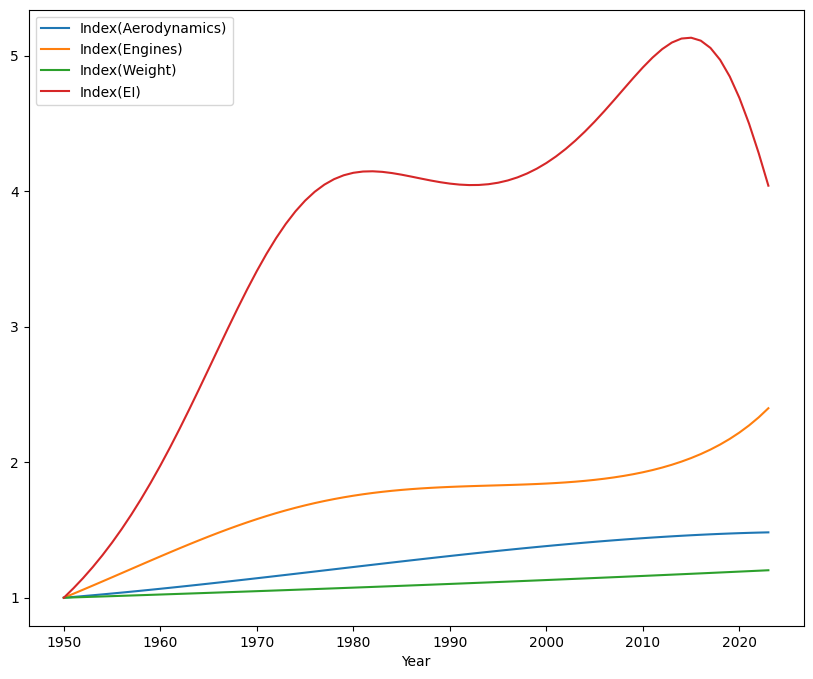

In [49]:
df_index.plot(
    x='Year',
    y=[
        'Index(Aerodynamics)',
        'Index(Engines)',
        'Index(Weight)',
        'Index(EI)',
    ],
    subplots=False,
    layout=(3,2),
    figsize=(10,8),
)